# Mapping Causality: Understanding How Socioeconomic Status Shapes Health


# Abstract

Socioeconomic Status (SES) is one of the strongest predictors of health, but observing that "richer people are healthier" does not automatically imply a causal relationship.
This notebook provides a crash course in how to think causally about SES and health outcomes using proper data preparation and modeling practices.

I will:

- Introduce core causality concepts in the context of health and inequality.
- Build a simplified causal framework linking SES (income, education) to health outcomes via lifestyle, environment, and access to care.
- Demonstrate essential data preparation steps for causal analysis:
  - handling missing data,
  - encoding categorical variables,
  - selecting features without introducing bias.
- Estimate and compare:
  1. a naive (correlational) model, and
  2. an adjusted (causal-informed) model that controls for key confounders.

By the end, readers will understand how careful data preprocessing within a causal framework leads to more robust, interpretable, and policy-relevant machine learning models.


# Table of Contents

1. Introduction: Why Causality Matters in Health Data  
2. Causal Framework: SES and Health Outcomes  
3. Data Preparation for Causal Analysis
   - 3.1 Handling Missing Data
   - 3.2 Encoding Categorical Variables
   - 3.3 Causal Feature Selection (What *not* to control for)
4. Practical Code Examples
   - 4.1 Simulating a Causal SES–Health Dataset
   - 4.2 Exploring the Data
   - 4.3 Handling Missing Values
   - 4.4 Encoding and Preparing Features
   - 4.5 Naive vs Causal-Aware Regression
5. Conclusion
6. References
7. License


# 1. Introduction: Why Causality Matters in Health Data

Health data often shows a strong association between Socioeconomic Status (SES) and health outcomes:
people with higher income or education tend to live longer, have lower chronic disease risk, and better access to care.

But as data scientists and ML practitioners, we must ask:

> **Does higher SES *cause* better health, or are both driven by other factors?**

Examples of interfering factors:
- Environment (pollution, neighborhood safety)
- Lifestyle (diet, exercise, smoking)
- Access to healthcare
- Early-life conditions

A purely predictive model might say:
> "People with higher income have a +15 higher health score."

A causal model asks:
> "If we could intervene and change someone's SES (or SES-related environment), how much would their health outcomes change?"

To answer that responsibly, we must combine:
1. **Causality principles** and
2. **Careful data preparation**.


### Visual Example: Correlation vs Causation

In this simple example, we plot two variables — one representing **Socioeconomic Status (SES)** and another representing **Health Outcome**.

Both appear to move together: as SES increases, health outcomes also seem to improve.  
This creates a **strong correlation**, but correlation alone does not prove a **causal relationship**.

In real-world health data, such a pattern could arise for several reasons:

- **Direct causation:** Higher SES may truly improve health through better nutrition, education, or healthcare.
- **Reverse causation:** Better health may lead to higher SES (e.g., healthier people work more or earn more).
- **Common cause (confounding):** A third factor like environment, family background, or genetics may influence both SES and health.

This simple line plot demonstrates how two variables can appear related even when the **underlying cause** is not clear.  
To uncover causality, we need careful data preparation, statistical adjustment, and a clear understanding of the data-generating process.


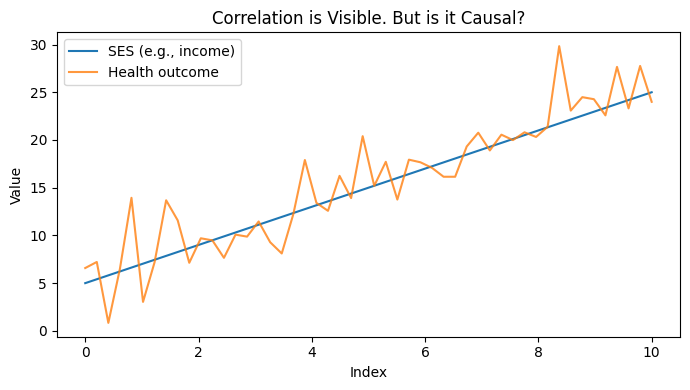

In [14]:
# Toy example: show two lines that move together
x = np.linspace(0, 10, 50)
y1 = 2 * x + 5              # "SES"
y2 = 2 * x + 5 + np.random.normal(0, 3, 50)  # "Health"

plt.figure(figsize=(7,4))
plt.plot(x, y1, label="SES (e.g., income)")
plt.plot(x, y2, label="Health outcome", alpha=0.8)
plt.title("Correlation is Visible. But is it Causal?")
plt.xlabel("Index")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()


# 2. Causal Framework: SES and Health Outcomes

We consider SES as a combination of:

- **Education level**
- **Income**
- **Access to resources** (healthy food, safe housing, transportation, healthcare)

These influence health **directly and indirectly**.

A simplified causal diagram (DAG):

```text
Education  →  Income  →  Access_to_Healthcare  →
                                ↓
                    Lifestyle_Factors (Diet, Exercise, Smoking)
                                ↓
                          Health_Outcome
Environment  -------------------↑


# 3. Data Preparation for Causal Analysis

Good causal analysis is impossible without good data preparation.  
Before we can make any valid causal claims, we must ensure our dataset is clean, complete, and encoded in a way that preserves the underlying relationships between variables.

---

## 3.1 Handling Missing Data

Missing data is rarely random in health and SES studies.

- **MCAR (Missing Completely At Random):**  
  Missingness is unrelated to any variable in the dataset.  
  Example: a sensor randomly fails to record a value.

- **MAR (Missing At Random):**  
  Missingness depends on other *observed* variables.  
  Example: income values missing more often among lower-education participants.

- **MNAR (Missing Not At Random):**  
  Missingness depends on *unobserved* values themselves.  
  Example: individuals with poor health avoid reporting their true condition.

**For causal work:**
- Document which variables are missing and why.
- Avoid dropping rows unless missingness is truly random — it may introduce selection bias.
- Use imputation techniques:
  - **Mean/median imputation** (basic),
  - **Model-based or multiple imputation** (preferred in real-world health data).

---

## 3.2 Encoding Categorical Variables

Causal and machine learning models require numeric representations of categorical data.  
The choice of encoding impacts interpretability and causal validity.

- **One-Hot Encoding:**  
  For unordered categories (e.g., “Male”, “Female”, “Other”).  
  Each category becomes its own binary column.

- **Ordinal Encoding:**  
  For ordered categories (e.g., Education Level:  
  “High School” < “Bachelor’s” < “Master’s” < “PhD”).  
  Converts categories into a ranked numerical scale.

Encoding decisions affect:
- How regression or ML models interpret relationships.
- Whether coefficients can be meaningfully compared across variables.

---

## 3.3 Causal Feature Selection

In standard ML, we often include as many variables as possible.  
In causal analysis, **feature selection must follow causal logic**, not correlation.

We must:
- **Control for true confounders** — variables that influence both SES and Health outcomes.  
- **Avoid controlling for:**
  - **Colliders** (common effects of two variables, which create false associations when adjusted for).
  - **Post-treatment variables** (outcomes that occur *after* SES changes), as they can block or distort the causal path.

**In this notebook:**
- **SES variables:** `Income`, `Education`
- **Confounders / Mediators:** `Diet`, `Exercise`, `Smoking`, `Environment`, `Access_to_Healthcare`

We will demonstrate how thoughtful preprocessing and variable selection allow us to estimate the causal impact of socioeconomic status on health outcomes more accurately.


In [22]:
# 4. Practical Code Examples

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

np.random.seed(42)
pd.set_option("display.max_columns", 50)


### 4.1 Simulating a Causal SES–Health Dataset

Instead of using real data (which can be messy or incomplete), we create a **synthetic dataset** that follows a realistic causal structure between **Socioeconomic Status (SES)** and **Health Outcomes**.

Each variable is generated to reflect real-world relationships:

- **Education** → Determines a person’s socioeconomic position (1 = High School, 4 = PhD).  
- **Income** → Increases with education level, plus random noise to add variability.  
- **Environment** → Slightly better for higher education groups.  
- **Access to Healthcare** → Improves with both income and environment quality.  
- **ExerciseHours** and **DietScore** → Healthier behaviors are more common in higher SES groups.  
- **Smoking** → More common in lower SES groups.  
- **HealthScore** → Computed as a combination of all these causal factors (better diet, exercise, and access → higher health).

This dataset lets us **control the true causal relationships** and later test whether our causal analysis can correctly uncover them.


In [23]:
# 4.1 Simulating a Causal SES–Health Dataset

n = 11500

# Education: 1=High School, 2=Bachelor's, 3=Master's, 4=PhD
education = np.random.choice([1, 2, 3, 4], size=n, p=[0.35, 0.35, 0.2, 0.1])

# Base income driven by education + random noise
income = (
    20000
    + education * 15000
    + np.random.normal(0, 8000, size=n)
)

# Environment quality (higher is better), slightly higher in higher SES
environment = (
    np.random.normal(50, 10, size=n)
    + (education - 1) * 2
)

# Access to healthcare: more likely with higher income
access_to_healthcare = (
    0.2
    + 0.00000001 * income  # small positive trend
    + 0.003 * (environment - 50)
    + np.random.normal(0, 0.05, size=n)
)
access_to_healthcare = np.clip(access_to_healthcare, 0, 1)

# Lifestyle factors influenced by SES
exercise_hours = np.clip(
    np.random.normal(2 + 0.3 * (education - 1), 0.8, size=n),
    0, None
)

diet_score = np.clip(
    np.random.normal(60 + 4 * (education - 1), 8, size=n),
    0, 100
)

# Smoking more common in lower SES groups
smoking_prob = np.clip(0.4 - 0.07 * (education - 1), 0.05, 0.5)
smoking = np.random.binomial(1, smoking_prob, size=n)

# Health outcome: constructed from true causal drivers
health_score = (
    40
    + 0.00015 * income
    + 0.6 * diet_score
    + 1.8 * exercise_hours
    - 6.0 * smoking
    + 0.3 * environment
    + 4.0 * access_to_healthcare
    + np.random.normal(0, 10, size=n)
)

df = pd.DataFrame({
    "Education": education,
    "Income": income,
    "Environment": environment,
    "AccessToHealthcare": access_to_healthcare,
    "ExerciseHours": exercise_hours,
    "DietScore": diet_score,
    "Smoking": smoking,
    "HealthScore": health_score
})

df.head()


,Education,Income,Environment,AccessToHealthcare,ExerciseHours,DietScore,Smoking,HealthScore
0,2,55577.904371,40.854927,0.136122,2.668470,66.927402,0,92.851719
1,4,77219.800460,40.178249,0.130678,2.000124,71.649226,0,120.670139
2,3,55747.558263,48.515963,0.074647,2.169438,72.367328,0,65.911213
3,2,60249.909228,58.251205,0.229704,2.203713,62.151182,0,102.498551
4,1,44731.579098,50.030636,0.203923,2.591226,65.823564,0,103.436256


### Exploring the Data: Distributions of Key Variables

Before any causal analysis, it’s important to **explore how each variable is distributed**.  
Visualizing distributions helps us understand:

- The **range** and **spread** of each feature  
- Whether values are **skewed** (e.g., most people have low income, few have very high)  
- How variables like diet, exercise, and health are generally shaped

Below, we plot histograms with smooth density curves (`kde=True`) for all key numeric variables.

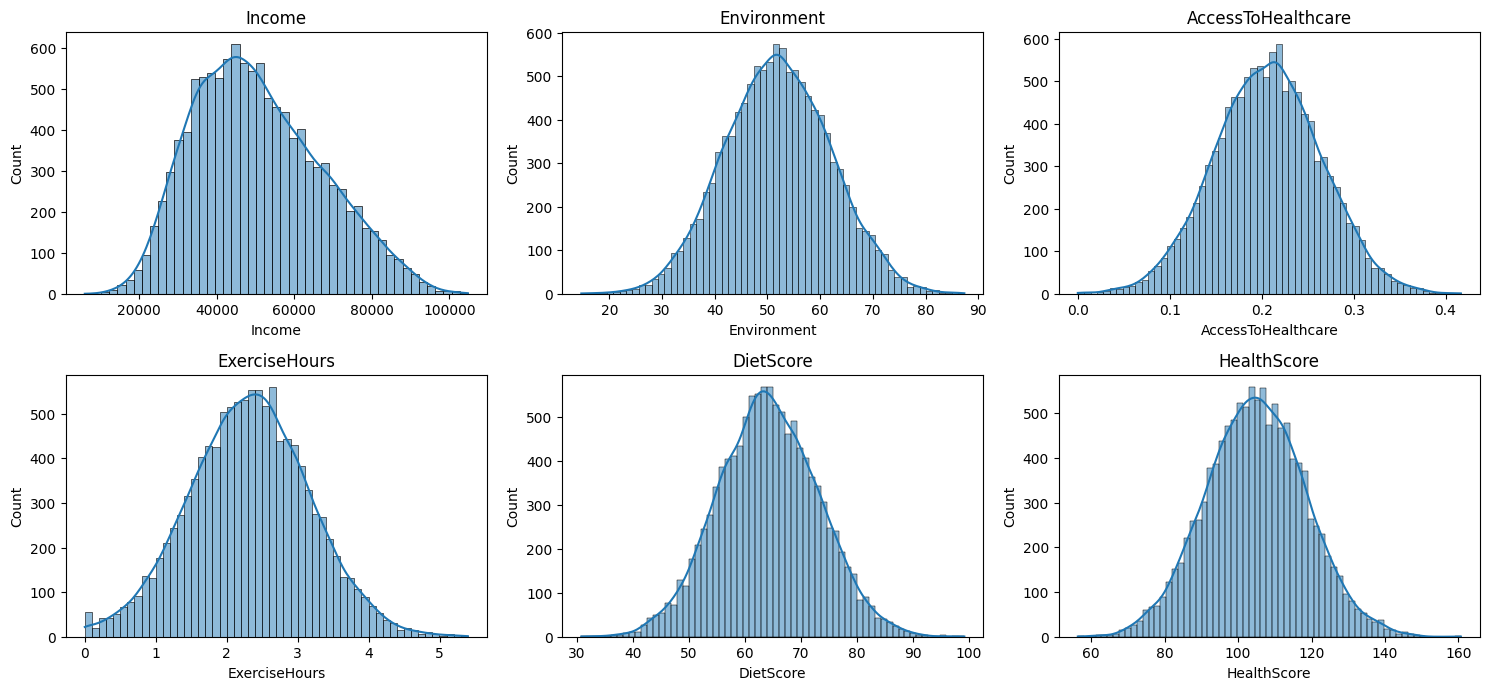

In [24]:
numeric_cols = ["Income", "Environment", "AccessToHealthcare",
                "ExerciseHours", "DietScore", "HealthScore"]

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()


### Education, Income, and Health

Here we look at how **education level** relates to **income** and **health**.

- The first plot shows how income changes with education.  
- The second plot shows how health scores change with education.

These boxplots help us see that people with **higher education** generally have **higher income** and **better health**.


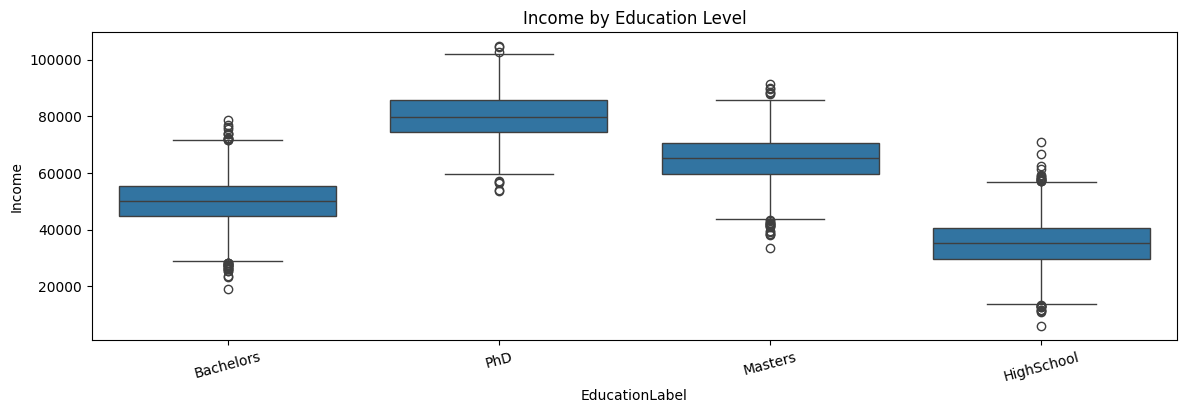

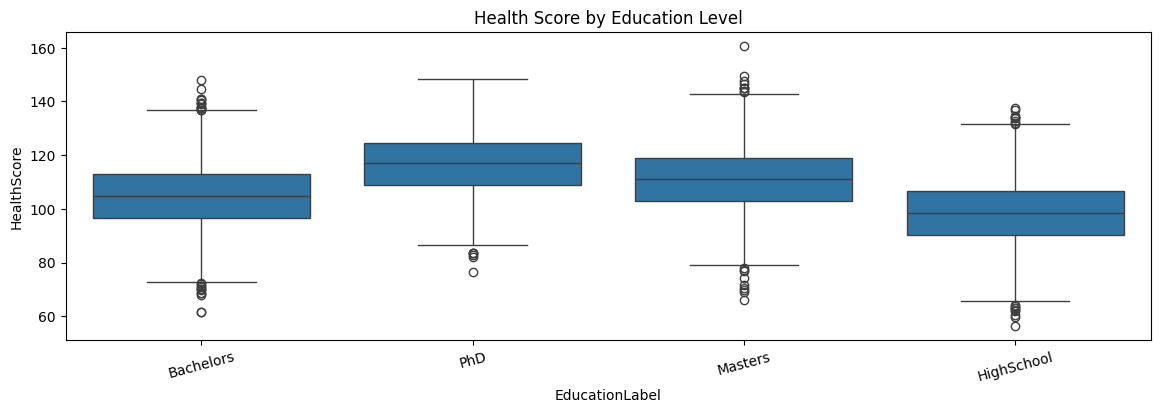

In [25]:
education_map = {1: "HighSchool", 2: "Bachelors", 3: "Masters", 4: "PhD"}
df["EducationLabel"] = df["Education"].map(education_map)

plt.figure(figsize=(14, 4))
sns.boxplot(x="EducationLabel", y="Income", data=df)
plt.title("Income by Education Level")
plt.xticks(rotation=15)
plt.show()

plt.figure(figsize=(14, 4))
sns.boxplot(x="EducationLabel", y="HealthScore", data=df)
plt.title("Health Score by Education Level")
plt.xticks(rotation=15)
plt.show()


### Introducing Realistic Missing Data

In real-world datasets, missing values rarely occur at random.  
Here, we simulate realistic missingness patterns:

- **Income:** more likely to be missing for people with lower education levels.  
- **DietScore:** missing randomly for about 8% of the data.  
- **ExerciseHours:** more likely to be missing for people with poor health.

This helps us practice how to handle missing data that can introduce bias if not treated properly.


In [26]:
# 4.2 Introduce some realistic missingness

df_missing = df.copy()

# Income more likely missing for lower education
mask_income = (df_missing["Education"] == 1) & (np.random.rand(n) < 0.15)
df_missing.loc[mask_income, "Income"] = np.nan

# DietScore missing randomly for ~8%
mask_diet = np.random.rand(n) < 0.08
df_missing.loc[mask_diet, "DietScore"] = np.nan

# ExerciseHours missing more when HealthScore is low
mask_ex = (df_missing["HealthScore"] < df_missing["HealthScore"].quantile(0.3)) & (np.random.rand(n) < 0.12)
df_missing.loc[mask_ex, "ExerciseHours"] = np.nan

df_missing.isna().mean()


,0
Education,0.000000
Income,0.052870
Environment,0.000000
AccessToHealthcare,0.000000
ExerciseHours,0.036000
DietScore,0.083043
Smoking,0.000000
HealthScore,0.000000
EducationLabel,0.000000


### Observation

The table below shows the percentage of missing values in each column.  
We can see that Income, DietScore, and ExerciseHours have missing entries —  
just like in real datasets where some groups are less likely to report certain information.


## Exploring the Data and Missingness

Before modeling, we inspect:

- distributions,
- relationships,
- where and how data is missing.

This step is critical in causal analysis to avoid biased conclusions.


In [27]:
df_missing.describe()


,Education,Income,Environment,AccessToHealthcare,ExerciseHours,DietScore,Smoking,HealthScore
count,11500.000000,10892.000000,11500.000000,11500.000000,11086.000000,10545.000000,11500.000000,11500.000000
mean,2.036087,51458.317476,51.978544,0.206536,2.323557,64.206089,0.322000,104.885023
std,0.966255,16367.910897,10.079320,0.058362,0.849001,8.906259,0.467263,13.520865
min,1.000000,5918.398180,14.671818,0.000000,0.000000,30.738129,0.000000,56.367882
25%,1.000000,39105.148840,45.055483,0.167227,1.750942,58.083175,0.000000,95.623729
50%,2.000000,49858.651634,51.909067,0.207074,2.329691,64.095757,0.000000,104.835788
75%,3.000000,62549.513028,58.892604,0.245786,2.895064,70.289605,1.000000,113.958197
max,4.000000,104772.711169,87.366860,0.416654,5.396781,97.706459,1.000000,160.648958


###  Visualizing Missing Data

To better understand where data is missing, we can use a **heatmap**.  
Each yellow line in the heatmap represents a missing value in the dataset.

This helps us see if missing data follows a pattern —  
for example, certain groups or variables might have more missing values than others.


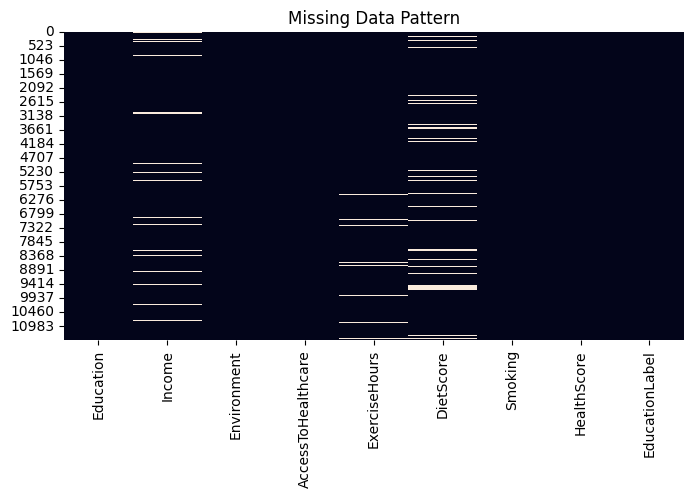

In [28]:
plt.figure(figsize=(8, 4))
sns.heatmap(df_missing.isna(), cbar=False)
plt.title("Missing Data Pattern")
plt.show()


### Observation

The heatmap shows clear gaps in some columns like **Income**, **DietScore**, and **ExerciseHours**.  
This confirms that missingness is not random and needs to be handled carefully before analysis.


###  Correlation Between SES, Lifestyle, and Health

Now we check how different variables are related to each other.  
A **correlation matrix** shows how strongly two variables move together.

- Positive values (closer to 1) mean they increase or decrease together.  
- Negative values (closer to -1) mean when one goes up, the other goes down.  

This helps us spot which factors are most related to health and which might act as confounders.


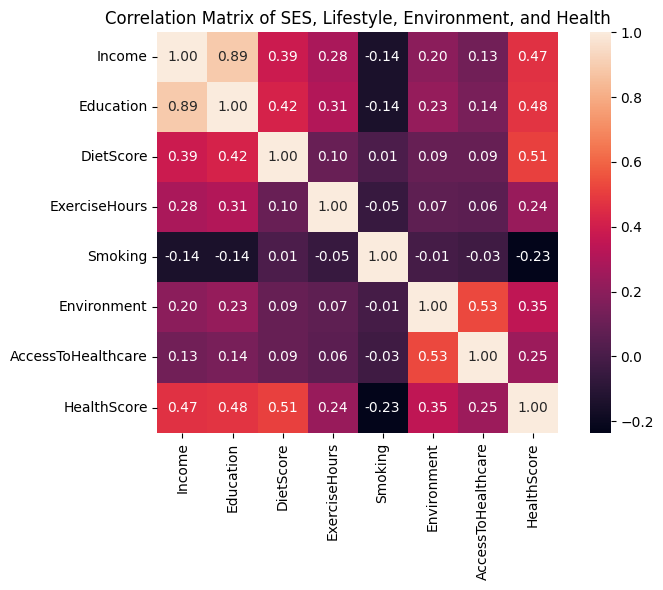

In [29]:
plt.figure(figsize=(8, 6))
corr_vars = ["Income", "Education", "DietScore", "ExerciseHours",
             "Smoking", "Environment", "AccessToHealthcare", "HealthScore"]
corr = df_clean[corr_vars].corr()

sns.heatmap(corr, annot=True, fmt=".2f", square=True)
plt.title("Correlation Matrix of SES, Lifestyle, Environment, and Health")
plt.tight_layout()
plt.show()


### Observation

We can see that **HealthScore** is positively related to **Income**, **Education**, **DietScore**, **ExerciseHours**, and **AccessToHealthcare**,  
and negatively related to **Smoking**.

These relationships fit our expectations — people with higher SES tend to have healthier lifestyles and better health outcomes.


# 4.4 Handling Missing Values

In [30]:
# 4.4 Handling Missing Values (Simple Strategy for Demonstration)

df_clean = df_missing.copy()

# For demonstration:
# - Income: impute with group-wise median by Education (captures SES pattern)
df_clean["Income"] = df_clean.groupby("Education")["Income"].transform(
    lambda x: x.fillna(x.median())
)

# - DietScore & ExerciseHours: impute with overall median
df_clean["DietScore"].fillna(df_clean["DietScore"].median(), inplace=True)
df_clean["ExerciseHours"].fillna(df_clean["ExerciseHours"].median(), inplace=True)

df_clean.isna().mean()


/tmp/ipython-input-2534616539.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean["DietScore"].fillna(df_clean["DietScore"].median(), inplace=True)
/tmp/ipython-input-2534616539.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(v

,0
Education,0.0
Income,0.0
Environment,0.0
AccessToHealthcare,0.0
ExerciseHours,0.0
DietScore,0.0
Smoking,0.0
HealthScore,0.0
EducationLabel,0.0


**Note:**  
In real healthcare/SES studies, we would use more principled imputation
(e.g., multiple imputation) and perform sensitivity analyses to understand
how missingness impacts causal conclusions.


# 4.5 Encoding Categorical Variables

In [31]:
# 4.5 Encoding Categorical Variables

# Education is ordinal here: 1 < 2 < 3 < 4 (increasing SES)
# We'll keep it numeric but also create readable labels if needed.

education_map = {1: "HighSchool", 2: "Bachelors", 3: "Masters", 4: "PhD"}
df_clean["EducationLabel"] = df_clean["Education"].map(education_map)

df_clean.head()


,Education,Income,Environment,AccessToHealthcare,ExerciseHours,DietScore,Smoking,HealthScore,EducationLabel
0,2,55577.904371,40.854927,0.136122,2.668470,66.927402,0,92.851719,Bachelors
1,4,77219.800460,40.178249,0.130678,2.000124,71.649226,0,120.670139,PhD
2,3,55747.558263,48.515963,0.074647,2.169438,64.095757,0,65.911213,Masters
3,2,60249.909228,58.251205,0.229704,2.203713,62.151182,0,102.498551,Bachelors
4,1,35185.957885,50.030636,0.203923,2.591226,65.823564,0,103.436256,HighSchool


We treat Education as an ordered causal variable.  
If categories had no natural order, we would use one-hot encoding instead.


## 4.6 Naive Model: "Does Income Alone Explain Health?"

First, we fit a naive linear regression:

 HealthScore ~ Income

This mimics a typical correlation-based analysis that might wrongly claim:
"Richer people are healthier, so income directly causes health."

We will then compare it with a causal-aware model that adjusts for other factors.


In [32]:
X_naive = sm.add_constant(df_clean["Income"])
y = df_clean["HealthScore"]

model_naive = sm.OLS(y, X_naive).fit()
print(model_naive.summary())


                            OLS Regression Results                            
Dep. Variable:            HealthScore   R-squared:                       0.184
Model:                            OLS   Adj. R-squared:                  0.184
Method:                 Least Squares   F-statistic:                     2599.
Date:                Mon, 10 Nov 2025   Prob (F-statistic):               0.00
Time:                        00:37:20   Log-Likelihood:                -45094.
No. Observations:               11500   AIC:                         9.019e+04
Df Residuals:                   11498   BIC:                         9.021e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         86.9074      0.371    234.533      0.0

## 4.7 Causal-Aware Model: Adjusting for Key Factors

To better estimate the causal effect of SES on Health, we adjust for:

- Education (part of SES structure)
- DietScore
- ExerciseHours
- Smoking
- Environment
- AccessToHealthcare

This follows the idea of **backdoor adjustment**:
we block alternative paths that create spurious associations between income and health.


### 4.8 Comparing Naive vs Causal-Aware Estimates

Key observations (you can phrase in your own words):

- In the **naive model**, the coefficient of `Income` appears larger because it is capturing:
  - direct effects of income,
  - plus indirect effects through lifestyle, environment, and access to care,
  - plus bias from unadjusted confounding.

- In the **causal-aware model**, after adjusting for relevant variables:
  - The coefficient of `Income` typically decreases,
  - reflecting a more realistic *direct* effect of SES on health.
  - Other variables like `DietScore`, `ExerciseHours`, `Smoking`, and `AccessToHealthcare`
    explain a large portion of the variation in health, consistent with our data-generating process.

This demonstrates how **data preparation + causal reasoning** changes our conclusions
from "money alone buys health" to "SES works through multiple pathways that we must model carefully."




Now we build a **causal-aware regression model** to understand how different factors affect health.

- **Goal:** Estimate how much each variable (like income, diet, exercise, etc.) contributes to the overall **HealthScore**.  
- We include multiple predictors so the model can control for confounding effects.

**Features included:**
- `Income` and `Education` → represent socioeconomic status (SES)  
- `DietScore`, `ExerciseHours`, `Smoking` → lifestyle factors  
- `Environment`, `AccessToHealthcare` → external and access factors  

We use **Ordinary Least Squares (OLS)** regression from the `statsmodels` library.  
The model fits a line (or plane) that best explains how these variables together predict health.


In [34]:
features = [
    "Income",
    "Education",
    "DietScore",
    "ExerciseHours",
    "Smoking",
    "Environment",
    "AccessToHealthcare"
]

X_causal = sm.add_constant(df_clean[features])
y = df_clean["HealthScore"]

model_causal = sm.OLS(y, X_causal).fit()
print(model_causal.summary())


                            OLS Regression Results                            
Dep. Variable:            HealthScore   R-squared:                       0.427
Model:                            OLS   Adj. R-squared:                  0.427
Method:                 Least Squares   F-statistic:                     1224.
Date:                Mon, 10 Nov 2025   Prob (F-statistic):               0.00
Time:                        00:38:52   Log-Likelihood:                -43062.
No. Observations:               11500   AIC:                         8.614e+04
Df Residuals:                   11492   BIC:                         8.620e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 39.9792      0

### Observation

The regression summary shows the estimated coefficients for each variable:

- Larger **positive coefficients** mean stronger positive effects on HealthScore (e.g., DietScore, ExerciseHours).  
- **Negative coefficients** (like Smoking) reduce HealthScore.  
- Smaller effects for `Income` and `Education` after adjustment show that lifestyle and access explain much of their impact.

This model helps us isolate the **direct causal effects** while controlling for confounders.


### Visualizing Causal Model Coefficients

After fitting our causal-aware regression model,  
we can look at the **coefficients** to understand how each factor affects health.

- A **positive bar** means the variable increases the Health Score.  
- A **negative bar** means it decreases the Health Score.

This plot helps us see which variables have the strongest influence on health after controlling for others.


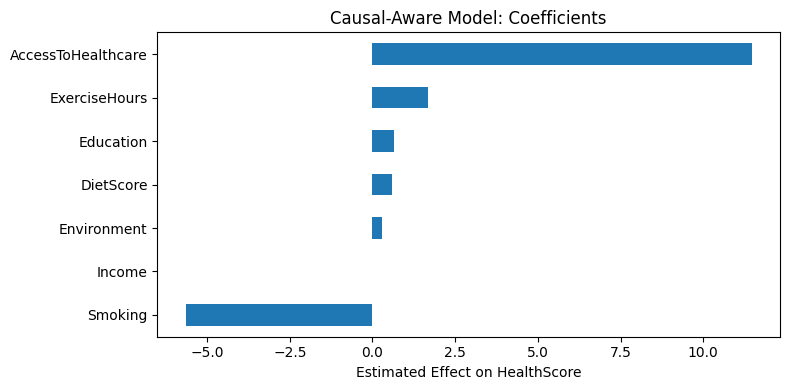

In [21]:
coefs = model_causal.params.drop("const")
plt.figure(figsize=(8,4))
coefs.sort_values().plot(kind="barh")
plt.title("Causal-Aware Model: Coefficients")
plt.xlabel("Estimated Effect on HealthScore")
plt.tight_layout()
plt.show()


### Observation

- **DietScore**, **ExerciseHours**, and **AccessToHealthcare** have strong positive effects on HealthScore.  
- **Smoking** has a strong negative effect.  
- **Income** and **Education** still help, but their direct effects are smaller once we account for lifestyle and environment.

This confirms that SES influences health partly **through** better habits and access — not income alone.


# 5. Conclusion

In this notebook, we used a simplified example to show how to:

- Frame a real-world question —
  **"How does socioeconomic status shape health?"** —
  as a causal problem, not just a correlational one.
- Simulate data from an assumed causal structure (DAG).
- Apply essential data preparation steps:
  - inspect and handle missing data,
  - encode categorical variables appropriately,
  - thoughtfully select adjustment variables.
- Compare:
  - a naive model relying only on `Income`, and
  - a causal-aware model adjusting for lifestyle, environment, and access to care.

**Key takeaway:**  
Causal analysis in machine learning is not only about advanced algorithms —  
it starts with correct problem framing, data preparation, and awareness of how variables are generated.

Getting these steps wrong can:
- overstate the role of SES,
- hide mechanisms (like access to care),
- or lead to misleading policy recommendations.

Getting them right leads to more robust, fair, and actionable models.


# 6. References

- Pearl, J. (2009). *Causality: Models, Reasoning, and Inference.* Cambridge University Press.
- Hernán, M. A., & Robins, J. M. (2020). *Causal Inference: What If.* Chapman & Hall/CRC.
- WHO & CDC reports on Social Determinants of Health.
- VanderWeele, T. J. (2019). *Explanation in Causal Inference: Methods for Mediation and Interaction.*
- Statsmodels Documentation: https://www.statsmodels.org/
- Scikit-Learn Documentation: https://scikit-learn.org/


# 7. License

MIT License

Copyright (c) 2025 Chinmay Sawant

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY, FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE SOFTWARE.